## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-13 11:52.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## Pulmonary venous EC

In [4]:
cell_type_filename = "diffExpResults_Pulmonary_venous_EC.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/Pulmonary_venous_EC/"

ct_label   = "Pulmonary venous EC"
ct_color   = '#2AA8C8'
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [5]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# pathway enrichment
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [6]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,XIST,7503.0,3.958932e-20,-0.450261,0.307,0.408,1.232218e-15,0.556483,0.702822
1,LDB2,9079.0,2.672474e-19,0.637643,0.883,0.856,8.318075e-15,2.338079,1.948288
2,VWF,7450.0,1.610868e-16,0.726291,0.960,0.928,5.013826e-12,2.329234,1.887490
3,SLCO2A1,6578.0,2.193459e-16,1.365394,0.978,0.842,6.827141e-12,2.691367,1.846265
4,ENG,2022.0,8.322072e-16,2.282313,0.653,0.217,2.590245e-11,0.967511,0.287682


In [7]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 1482, down: 317


In [8]:
print(glist_mild_up)

['LDB2', 'VWF', 'SLCO2A1', 'ENG', 'PLEKHA7', 'SMAD6', 'ID1', 'LEF1', 'RDH10', 'EBF4', 'PLPP3', 'PLA1A', 'THUMPD3-AS1', 'HYAL2', 'ACACA', 'GRK5', 'LINC01010', 'MT2A', 'RAMP3', 'MEF2D', 'ANO2', 'OSTC', 'PLLP', 'NADK', 'PIK3R3', 'TPST2', 'UTY', 'SPRY4-AS1', 'FKBP1A', 'RGCC', 'PITPNC1', 'FGR', 'TCF3', 'PTPRJ', 'FAM171A1', 'BMPR2', 'UTP6', 'ARAP3', 'RDH10-AS1', 'EPHB4', 'PLXNA2', 'SH3RF3', 'WARS', 'NPAS2', 'CD59', 'RNF145', 'ZNF410', 'EXOC6', 'PROCR', 'MTCL1', 'PVR', 'AC083855.2', 'REXO1', 'PALM2-AKAP2', 'GOLGA3', 'GFOD1', 'SPIRE1', 'LRP6', 'PCDH17', 'ADCY4', 'RUBCN', 'NOS3', 'MBD1', 'MGAT4A', 'ACKR1', 'FBXL7', 'HABP4', 'WSB1', 'CEMIP2', 'CMTM8', 'ST3GAL4', 'ABCB1', 'AL157871.4', 'AK2', 'SGK1', 'PPM1D', 'MRPS25', 'AL136985.3', 'DOCK6', 'RGS5', 'RPS6', 'BCAR3', 'ARRDC3-AS1', 'FCN3', 'FNDC3B', 'AP001605.1', 'ZSWIM6', 'SMURF2', 'CHMP1A', 'ATP13A3', 'FAT1', 'EFTUD2', 'TMCC3', 'SLC7A14-AS1', 'FAM124A', 'BMPER', 'NR2F2', 'DEDD', 'RAPGEF1', 'GBE1', 'RFC3', 'ZFHX3', 'ELF2', 'NUP160', 'COL4A2', 'ROB

  Saved: volcano_pulmonary_venous_EC_mild_vs_control.pdf


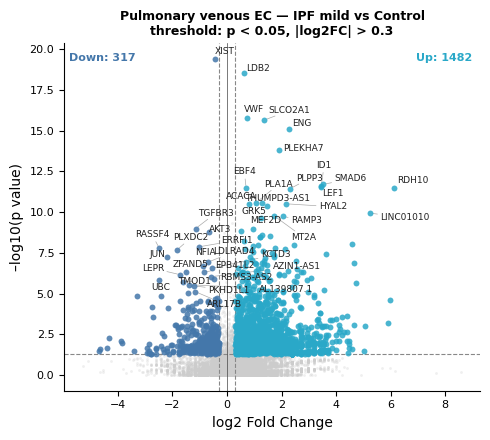

In [9]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_pulmonary_venous_EC_mild_vs_control.pdf")

In [10]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pathways

In [11]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Focal Adhesion Assembly (GO:0051...,15/53,0.000004,0.016447,0,0,4.972554,61.32432,ACVRL1;NRP1;MACF1;RCC2;FAM107A;PTEN;PTPRJ;LDB2...
1,GO_Biological_Process_2025,Negative Regulation of Cell-Matrix Adhesion (G...,10/30,0.000037,0.051095,0,0,6.283288,64.15958,ACVRL1;DUSP22;JAG1;ADAM15;RCC2;DLC1;FAM107A;PT...
2,GO_Biological_Process_2025,Venous Blood Vessel Development (GO:0060841),5/7,0.000041,0.051095,0,0,31.340560,316.55300,ACVRL1;BMPR2;FOXF1;APLNR;ENG
3,GO_Biological_Process_2025,Vasculogenesis (GO:0001570),10/33,0.000092,0.086089,0,0,5.462843,50.75550,NRP1;SPRED1;TGFB1;SOX18;APLNR;CCM2;EGFL8;RASIP...
4,GO_Biological_Process_2025,Sympathetic Neuron Projection Extension (GO:00...,4/5,0.000141,0.096168,0,0,50.113670,444.24080,NRP1;NRP2;SEMA3A;SEMA3F
5,GO_Biological_Process_2025,Positive Regulation of Intracellular Signal Tr...,73/652,0.000261,0.096168,0,0,1.605209,13.24188,BCAR3;ACVRL1;APP;GPR89A;BMPR2;SLC44A2;TRADD;PT...
6,GO_Biological_Process_2025,Host-Mediated Suppression of Symbiont Invasion...,7/19,0.000275,0.096168,0,0,7.318757,59.99797,IFITM3;SNX3;FCN3;GSN;IFITM2;TRIM5;LY6E
7,GO_Biological_Process_2025,Negative Regulation of Growth (GO:0045926),20/115,0.000284,0.096168,0,0,2.652891,21.66046,ACVRL1;SMAD3;TGFB1;BMPR2;DCUN1D3;EI24;MT1M;PTP...
8,GO_Biological_Process_2025,Axon Extension Involved in Axon Guidance (GO:0...,4/6,0.000399,0.096168,0,0,25.055480,196.10510,NRP1;NRP2;SEMA3A;SEMA3F
9,GO_Biological_Process_2025,Facial Nerve Morphogenesis (GO:0021610),4/6,0.000399,0.096168,0,0,25.055480,196.10510,NRP1;NRP2;SEMA3A;SEMA3F


In [12]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,16/54,0.000001,0.000040,0,0,5.307676,72.922470,BCAR3;SMAD1;BMPR2;TGFB1;SMAD3;SMURF2;XIAP;SMAD...
1,MSigDB_Hallmark_2020,Myc Targets V1,35/200,0.000002,0.000040,0,0,2.690436,35.899630,SET;SF3B3;DDX21;HNRNPR;PWP1;RPL6;PPM1G;PSMD8;S...
2,MSigDB_Hallmark_2020,mTORC1 Signaling,31/200,0.000072,0.001194,0,0,2.319637,22.138450,NUP205;TES;NUFIP1;PITPNB;GBE1;FGL2;ARPC5L;PIK3...
3,MSigDB_Hallmark_2020,UV Response Dn,22/144,0.000924,0.011556,0,0,2.272131,15.873820,NRP1;SMAD3;WDR37;ANXA2;PRKCE;PTEN;PIK3R3;PTPN2...
4,MSigDB_Hallmark_2020,Angiogenesis,8/36,0.004151,0.041512,0,0,3.584028,19.656080,APP;NRP1;THBD;JAG1;SLCO2A1;TIMP1;FSTL1;VAV2
5,MSigDB_Hallmark_2020,Unfolded Protein Response,16/113,0.009093,0.075772,0,0,2.072657,9.742077,NOP14;SHC1;FUS;SLC30A5;GOSR2;YWHAZ;RPS14;SPCS1...
6,MSigDB_Hallmark_2020,Inflammatory Response,24/200,0.013211,0.087852,0,0,1.715488,7.422473,LYN;CALCRL;PTAFR;ADRM1;ATP2A2;AHR;SLC4A4;HIF1A...
7,MSigDB_Hallmark_2020,Androgen Response,14/100,0.015474,0.087852,0,0,2.043977,8.520545,ABCC4;XRCC5;TMEM50A;ELOVL5;GSR;ADRM1;PTPN21;AC...
8,MSigDB_Hallmark_2020,Apoptosis,20/161,0.015813,0.087852,0,0,1.782946,7.393707,IFITM3;APP;GSN;LEF1;GSR;PPP2R5B;EMP1;XIAP;CLU;...
9,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,13/105,0.046511,0.232379,0,0,1.772412,5.437882,PTEN;PIK3R3;NOD1;IRAK4;ECSIT;ACACA;TBK1;PIN1;R...


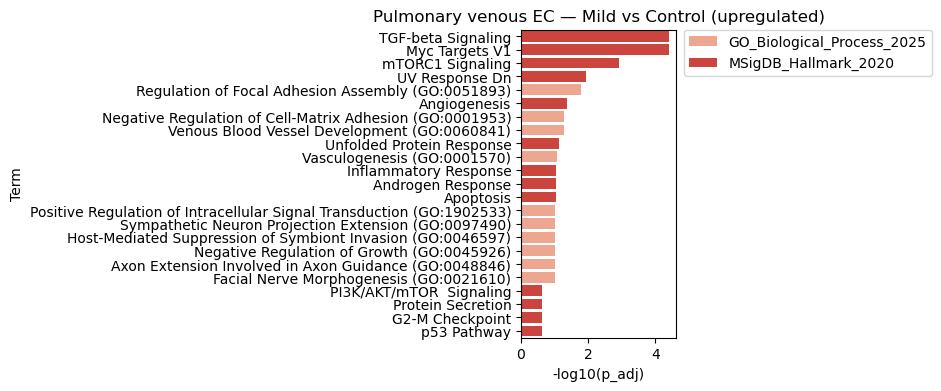

In [13]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="Pulmonary venous EC — Mild vs Control (upregulated)",
    savepath=f"{out_base}/pulmonary_venous_EC_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [14]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Cell Migration (GO:0030334),28/479,3.291922e-09,0.000006,0,0,4.131503,80.69567,CLIC4;FLT1;SYNPO2;SERPINE1;NEDD9;RORA;LDLRAD4;...
1,GO_Biological_Process_2025,Negative Regulation of Cell Motility (GO:2000146),13/139,3.392632e-07,0.000302,0,0,6.637453,98.87475,EPHA4;CD74;CLIC4;LIMCH1;CCDC125;SERPINE1;TPM1;...
2,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,14/184,1.488274e-06,0.000884,0,0,5.303475,71.16146,EPHA4;CD74;CLIC4;PTPRR;LIMCH1;SERPINE1;TPM1;NE...
3,GO_Biological_Process_2025,Positive Regulation of Cell Motility (GO:2000147),13/249,1.822028e-04,0.081126,0,0,3.523793,30.34123,SPAG9;EPHA4;EDN1;FLT1;INSR;SYNPO2;CAV1;NEDD9;R...
4,GO_Biological_Process_2025,Positive Regulation of Cell Migration (GO:0030...,15/344,4.194535e-04,0.126764,0,0,2.921858,22.72200,SPAG9;EPHA4;EDN1;FLT1;SYNPO2;INSR;CAV1;NEDD9;R...
5,GO_Biological_Process_2025,Cytoskeleton Organization (GO:0007010),8/117,5.574419e-04,0.126764,0,0,4.649268,34.83302,DST;TPM1;PACSIN2;NEDD9;PTK2B;LRCH3;CLASP1;SH3D19
6,GO_Biological_Process_2025,Regulation of Cell-Matrix Adhesion (GO:0001952),6/65,5.693881e-04,0.126764,0,0,6.416916,47.94045,LIMCH1;PTK2B;EMP2;CD36;CLASP1;CORO1C
7,GO_Biological_Process_2025,Regulation of Epithelial Cell Migration (GO:00...,5/43,5.694065e-04,0.126764,0,0,8.284835,61.89530,PTPRR;ANKRD44;CLASP1;RAB11A;CORO1C
8,GO_Biological_Process_2025,Plasma Membrane Invagination (GO:0099024),4/27,8.148577e-04,0.148798,0,0,10.923740,77.69506,ELMO1;SNX9;CD36;ARHGAP25
9,GO_Biological_Process_2025,Regulation of Small GTPase Mediated Signal Tra...,9/157,9.188706e-04,0.148798,0,0,3.856945,26.96917,PREX2;TIAM1;SPATA13;ARHGEF3;ARHGAP29;ARHGAP5;A...


In [15]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,13/200,0.000019,0.000894,0,0,4.458345,48.366140,JUN;BTG2;EDN1;TSC22D1;PLK2;SERPINE1;SLC2A3;NR4...
1,MSigDB_Hallmark_2020,Hypoxia,11/200,0.000364,0.007571,0,0,3.707750,29.357060,ERRFI1;JUN;CAV1;SERPINE1;MAFF;RORA;SLC2A3;CCN1...
2,MSigDB_Hallmark_2020,UV Response Dn,9/144,0.000494,0.007571,0,0,4.231169,32.213640,TGFBR3;ATXN1;SFMBT1;CAV1;SERPINE1;AKT3;ATRX;CC...
3,MSigDB_Hallmark_2020,Mitotic Spindle,10/199,0.001330,0.010584,0,0,3.359702,22.250690,TIAM1;PCM1;DST;EPB41L2;RASA1;ARHGEF3;NEDD9;ARH...
4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,10/200,0.001380,0.010584,0,0,3.341848,22.007120,TGFBR3;JUN;TPM4;DST;CALD1;SERPINE1;TPM1;TIMP3;...
5,MSigDB_Hallmark_2020,p53 Pathway,10/200,0.001380,0.010584,0,0,3.341848,22.007120,PTPRE;JUN;BTG2;TSC22D1;PLK2;COQ8A;TM7SF3;FOXO3...
6,MSigDB_Hallmark_2020,Apoptosis,8/161,0.004227,0.026430,0,0,3.304778,18.064740,TGFBR3;JUN;BTG2;GPX3;CAV1;TIMP3;NEDD9;ATF3
7,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,0.004596,0.026430,0,0,2.997898,16.136090,SOCS2;TIAM1;GABARAPL1;MAFF;SNX9;RORA;SLC2A3;ND...
8,MSigDB_Hallmark_2020,Cholesterol Homeostasis,5/74,0.006401,0.032716,0,0,4.555463,23.010990,ERRFI1;STX5;CD9;ATF3;GNAI1
9,MSigDB_Hallmark_2020,Coagulation,6/138,0.022822,0.104983,0,0,2.857498,10.801390,CPQ;SERPINE1;MAFF;TIMP3;CD9;C2


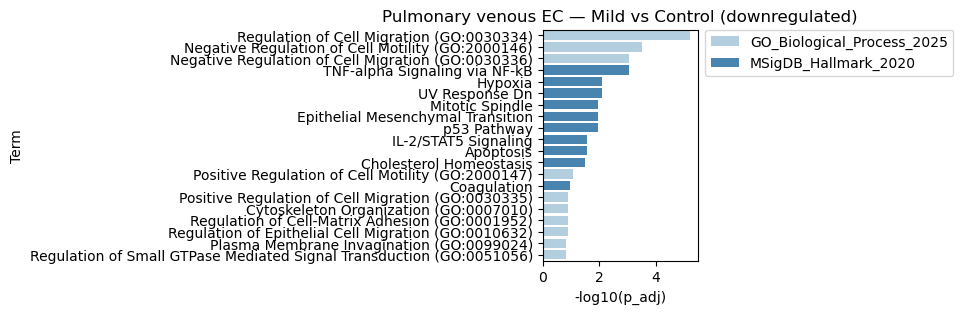

In [16]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="Pulmonary venous EC — Mild vs Control (downregulated)",
    savepath=f"{out_base}/Pulmonary_venous_EC_mild_down.pdf",
    palette="Blues",
)

## Severe vs control

In [17]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,FNTB,NaN,2.423283e-10,0.785261,0.085,0.047,0.000008,0.081678,0.051432
1,XIST,7503.0,7.708017e-09,-0.858377,0.202,0.408,0.000240,0.440312,0.702822
2,DCAF5,8816.0,3.248741e-07,1.004378,0.191,0.092,0.010112,0.201637,0.107857
3,IL18R1,8809.0,6.216892e-07,0.526980,0.404,0.319,0.019350,0.586604,0.443617
4,RANBP2,5903.0,1.606068e-06,-0.090216,0.096,0.133,0.049989,0.120144,0.134919


In [18]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 526, down: 74


  Saved: volcano_Pulmonary_venous_EC_severe_vs_control.pdf


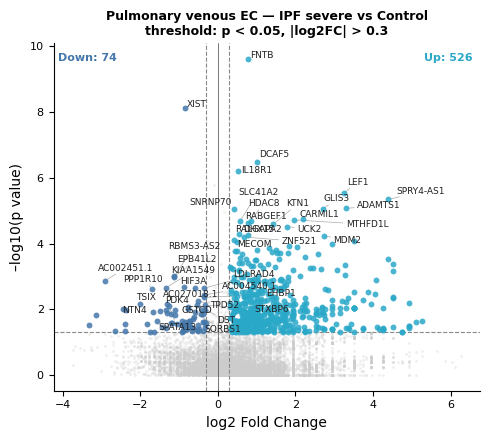

In [19]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_Pulmonary_venous_EC_severe_vs_control.pdf")

In [20]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [21]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,48/983,0.000029,0.069094,0,0,1.991077,20.80607,NFAT5;HDAC5;APP;CSRNP1;CIITA;FOXC1;NOTCH1;LEF1...
1,GO_Biological_Process_2025,Negative Regulation of DNA-templated Transcrip...,47/1006,0.000102,0.088720,0,0,1.894382,17.41360,HDAC5;APP;CIITA;FOXC1;SET;NOTCH1;CBFB;LEF1;ATN...
2,GO_Biological_Process_2025,Clathrin-Dependent Endocytosis (GO:0072583),6/30,0.000112,0.088720,0,0,9.350962,85.10337,ITSN2;INPP5F;DNAJC6;ITSN1;FNBP1L;SCYL2
3,GO_Biological_Process_2025,Negative Regulation of Glycogen Biosynthetic P...,3/6,0.000341,0.134852,0,0,37.229450,297.23150,SELENOS;GRB10;INPP5K
4,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,54/1274,0.000366,0.134852,0,0,1.711788,13.54311,APP;CSRNP1;CIITA;AHR;FGF1;ZNF609;TBK1;MED13;ME...
5,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,85/2250,0.000369,0.134852,0,0,1.540971,12.18253,APP;CSRNP1;CIITA;ATN1;JMJD1C;AHR;FGF1;DCAF1;ZN...
6,GO_Biological_Process_2025,Vesicle Cytoskeletal Trafficking (GO:0099518),5/25,0.000424,0.134852,0,0,9.334933,72.49062,KIF5B;FNBP1L;DYNC1I1;TANC2;SLC6A4
7,GO_Biological_Process_2025,Positive Regulation of miRNA Metabolic Process...,7/53,0.000452,0.134852,0,0,5.696406,43.87091,MYC;ATOH8;MRTFB;KLF4;HIF1A;NFKB1;SMARCA4
8,GO_Biological_Process_2025,Regulation of Chemokine-Mediated Signaling Pat...,3/7,0.000585,0.155092,0,0,27.920650,207.83820,HIF1A;SH2B3;ROBO1
9,GO_Biological_Process_2025,Negative Regulation of RNA Biosynthetic Proces...,25/470,0.000738,0.176094,0,0,2.133822,15.38811,HDAC5;CIITA;SET;NOTCH1;LEF1;AHR;SCML1;MECOM;AT...


In [22]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Estrogen Response Early,13/200,0.002529,0.059177,0,0,2.613660,15.629410,FOXC1;ELOVL5;ABHD2;TPBG;SLC1A1;ENDOD1;KLF4;PAP...
1,MSigDB_Hallmark_2020,TGF-beta Signaling,6/54,0.002851,0.059177,0,0,4.669712,27.365660,BCAR3;FKBP1A;WWTR1;SMURF2;ID3;ENG
2,MSigDB_Hallmark_2020,Wnt-beta Catenin Signaling,5/42,0.004707,0.059177,0,0,5.041500,27.016050,HDAC5;KAT2A;NOTCH1;MYC;LEF1
3,MSigDB_Hallmark_2020,UV Response Dn,10/144,0.004831,0.059177,0,0,2.797061,14.916040,INPP4B;EFEMP1;RBPMS;ANXA2;MYC;PIK3R3;NR1D2;LAM...
4,MSigDB_Hallmark_2020,Apical Junction,12/200,0.006841,0.067042,0,0,2.394983,11.938560,VWF;ACTN1;ADAM23;LAMA3;FSCN1;NF1;PIK3R3;ADAM9;...
5,MSigDB_Hallmark_2020,Angiogenesis,4/36,0.014319,0.114924,0,0,4.655651,19.768650,APP;POSTN;SLCO2A1;PTK2
6,MSigDB_Hallmark_2020,Androgen Response,7/100,0.016418,0.114924,0,0,2.810761,11.550520,INPP4B;TMEM50A;ADAMTS1;ELOVL5;ACTN1;ABHD2;ARID5B
7,MSigDB_Hallmark_2020,Unfolded Protein Response,7/113,0.029747,0.182197,0,0,2.464391,8.662441,XPOT;MTHFD2;FUS;KIF5B;EIF2S1;SEC11A;SEC31A
8,MSigDB_Hallmark_2020,Myc Targets V1,10/200,0.039277,0.213842,0,0,1.966952,6.367245,CCT3;PSMA6;SET;XPOT;MYC;DHX15;CTPS1;EIF2S1;KPN...
9,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,6/105,0.058788,0.288060,0,0,2.258159,6.399219,PLA2G12A;MAPK8;TBK1;ARHGDIA;PIK3R3;IRAK4


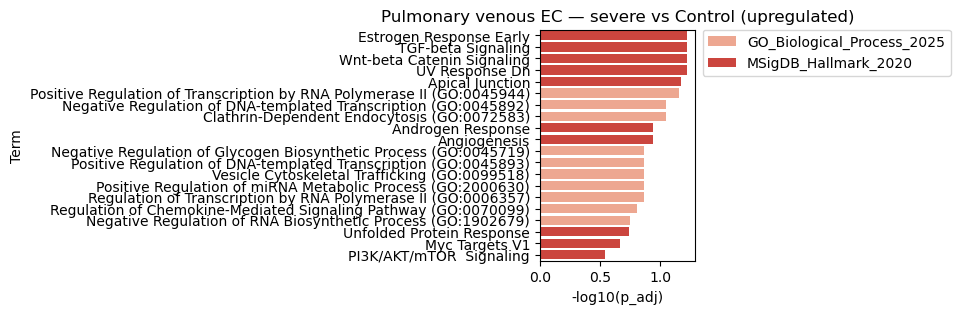

In [23]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="Pulmonary venous EC — severe vs Control (upregulated)",
    savepath=f"{out_base}/Pulmonary_venous_EC_severe_up.pdf",
)

### Downregulated pathways

In [24]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,"Regulation of mRNA Splicing, via Spliceosome (...",4/97,0.000461,0.201578,0,0,12.186180,93.60824,RBM39;TRA2B;ARGLU1;SRRM1
1,GO_Biological_Process_2025,Negative Regulation of Cilium Assembly (GO:190...,2/21,0.002710,0.232163,0,0,29.103800,172.02850,ODF2L;WDR44
2,GO_Biological_Process_2025,"RNA Splicing, via Transesterification Reaction...",2/24,0.003536,0.232163,0,0,25.131310,141.85970,TRA2B;SRRM1
3,GO_Biological_Process_2025,Positive Regulation of Erythrocyte Differentia...,2/27,0.004465,0.232163,0,0,22.112220,119.66060,MIA3;GLUL
4,GO_Biological_Process_2025,Regulation of Lipid Biosynthetic Process (GO:0...,2/28,0.004797,0.232163,0,0,21.260680,113.52770,PDK4;SORBS1
5,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,4/184,0.004834,0.232163,0,0,6.268571,33.42445,PTPRR;ARID4A;MIA3;LDLRAD4
6,GO_Biological_Process_2025,Cell-Substrate Junction Assembly (GO:0007044),2/29,0.005140,0.232163,0,0,20.472220,107.90340,DST;SORBS1
7,GO_Biological_Process_2025,Regulation of RNA Splicing (GO:0043484),3/104,0.006777,0.232163,0,0,8.293822,41.42093,RBM39;TRA2B;SRRM1
8,GO_Biological_Process_2025,Negative Regulation of Plasma Membrane Bounded...,2/36,0.007844,0.232163,0,0,16.251630,78.78859,ODF2L;WDR44
9,GO_Biological_Process_2025,Positive Regulation of Myeloid Cell Differenti...,2/37,0.008272,0.232163,0,0,15.786510,75.69397,MIA3;GLUL


In [25]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Apoptosis,3/161,0.021886,0.196813,0,0,5.286504,20.204470,JUN;IFNGR1;PLAT
1,MSigDB_Hallmark_2020,Mitotic Spindle,3/199,0.037582,0.196813,0,0,4.253377,13.956330,DST;RASA1;EPB41L2
2,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,3/200,0.038056,0.196813,0,0,4.231572,13.831770,JUN;TSC22D1;DNAJB4
3,MSigDB_Hallmark_2020,Adipogenesis,3/200,0.038056,0.196813,0,0,4.231572,13.831770,IFNGR1;UBC;SORBS1
4,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,2/87,0.041285,0.196813,0,0,6.483987,20.666130,JUN;IFNGR1
5,MSigDB_Hallmark_2020,Protein Secretion,2/96,0.049272,0.196813,0,0,5.860520,17.642460,TPD52;DST
6,MSigDB_Hallmark_2020,Androgen Response,2/100,0.052988,0.196813,0,0,5.620181,16.510340,TPD52;TSC22D1
7,MSigDB_Hallmark_2020,Fatty Acid Metabolism,2/158,0.116059,0.274912,0,0,3.520299,7.581506,XIST;GLUL
8,MSigDB_Hallmark_2020,Hedgehog Signaling,1/36,0.125028,0.274912,0,0,7.785127,16.186950,RASA1
9,MSigDB_Hallmark_2020,Hypoxia,2/200,0.169177,0.274912,0,0,2.767677,4.917637,TPD52;JUN


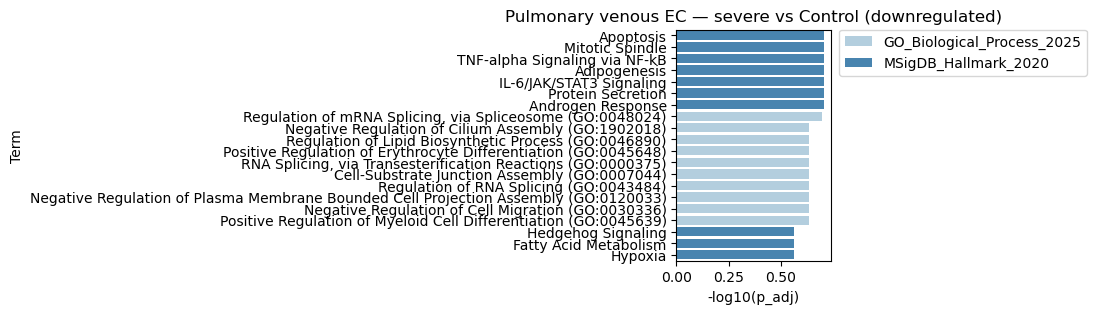

In [26]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="Pulmonary venous EC — severe vs Control (downregulated)",
    savepath=f"{out_base}/Pulmonary_venous_EC_severe_down.pdf",
    palette="Blues",
)

In [27]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Mild vs Control — up: 1482, down: 317
Severe vs Control — up: 526, down: 74


In [28]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

Upregulated genes (Mild vs Control):
['LDB2', 'VWF', 'SLCO2A1', 'ENG', 'PLEKHA7', 'SMAD6', 'ID1', 'LEF1', 'RDH10', 'EBF4', 'PLPP3', 'PLA1A', 'THUMPD3-AS1', 'HYAL2', 'ACACA', 'GRK5', 'LINC01010', 'MT2A', 'RAMP3', 'MEF2D', 'ANO2', 'OSTC', 'PLLP', 'NADK', 'PIK3R3', 'TPST2', 'UTY', 'SPRY4-AS1', 'FKBP1A', 'RGCC', 'PITPNC1', 'FGR', 'TCF3', 'PTPRJ', 'FAM171A1', 'BMPR2', 'UTP6', 'ARAP3', 'RDH10-AS1', 'EPHB4', 'PLXNA2', 'SH3RF3', 'WARS', 'NPAS2', 'CD59', 'RNF145', 'ZNF410', 'EXOC6', 'PROCR', 'MTCL1', 'PVR', 'AC083855.2', 'REXO1', 'PALM2-AKAP2', 'GOLGA3', 'GFOD1', 'SPIRE1', 'LRP6', 'PCDH17', 'ADCY4', 'RUBCN', 'NOS3', 'MBD1', 'MGAT4A', 'ACKR1', 'FBXL7', 'HABP4', 'WSB1', 'CEMIP2', 'CMTM8', 'ST3GAL4', 'ABCB1', 'AL157871.4', 'AK2', 'SGK1', 'PPM1D', 'MRPS25', 'AL136985.3', 'DOCK6', 'RGS5', 'RPS6', 'BCAR3', 'ARRDC3-AS1', 'FCN3', 'FNDC3B', 'AP001605.1', 'ZSWIM6', 'SMURF2', 'CHMP1A', 'ATP13A3', 'FAT1', 'EFTUD2', 'TMCC3', 'SLC7A14-AS1', 'FAM124A', 'BMPER', 'NR2F2', 'DEDD', 'RAPGEF1', 'GBE1', 'RFC3', 'ZFH

In [29]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

Upregulated genes (Severe vs Control):
['FNTB', 'DCAF5', 'IL18R1', 'LEF1', 'SPRY4-AS1', 'ADAMTS1', 'SNRNP70', 'GLIS3', 'CARMIL1', 'MTHFD1L', 'HDAC8', 'SLC41A2', 'RABGEF1', 'KTN1', 'UCK2', 'RALGAPA2', 'DHX15', 'MDM2', 'ZNF521', 'MECOM', 'NLGN1', 'ITPRIP-AS1', 'LAMC1', 'ATOH8', 'ENG', 'SH2D3C', 'APLF', 'NR2F2-AS1', 'GOLGA3', 'PTBP2', 'ZFYVE28', 'ATP11A', 'NARF', 'UBE2V2', 'RPL39', 'TCF12', 'RBPMS', 'FAM20B', 'FAM78B', 'FNBP1L', 'BUD23', 'SPRY1', 'HS2ST1', 'BID', 'RAB2B', 'CTTNBP2NL', 'GMDS', 'OGFOD3', 'DAPK1', 'TANC2', 'FAM171A1', 'CMIP', 'MAGI1', 'RFX3', 'ZNF684', 'ROBO1', 'RTCB', 'DYM', 'RNF145', 'RAPGEF4', 'FBLIM1', 'SETBP1', 'RGS5', 'HDAC5', 'FGF1', 'MAPK8', 'NPAS2', 'NUDT9', 'NOL4L', 'ZMYM6', 'ZNF431', 'NRG1', 'MACF1', 'UBE2L3', 'SMARCA4', 'SMURF2', 'AP3B1', 'PVT1', 'TLL1', 'ITSN1', 'RPL5', 'ATR', 'MPZL2', 'PAPSS2', 'ADAM23', 'SOBP', 'TCF3', 'UGCG', 'MTMR4', 'DCAF10', 'ZNF346', 'AC021231.1', 'SEC11A', 'CHSY1', 'WASHC5-AS1', 'SCML1', 'RGCC', 'GFOD2', 'SNRK', 'TRMU', 'FKBP1A', 'CCDC12

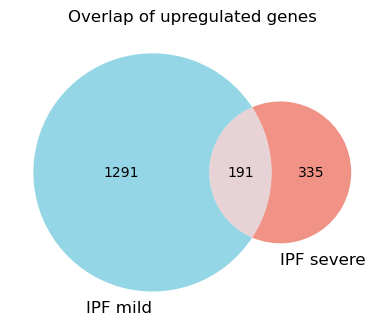

Overlap genes: 191
['ABCB1', 'AC090617.4', 'ACSL4', 'ADAM23', 'ADAMTS1', 'ADAMTS3', 'ADAMTS6', 'ADCY4', 'ADPRM', 'AHR', 'AIM2', 'AK2', 'AL049828.1', 'AL136171.2', 'AL136985.3', 'AL353138.1', 'ANO2', 'ANXA2', 'AP3B1', 'APP', 'ARAP3', 'ARHGAP23', 'ARHGAP31', 'ARPC5L', 'ASAP3', 'ATG5', 'ATOH8', 'BCAR3', 'BID', 'BTRC', 'BUD23', 'CASKIN2', 'CBFB', 'CCT3', 'CD164', 'CDYL2', 'CERS6', 'CHSY1', 'CIAPIN1', 'CMIP', 'CMTM8', 'CPNE5', 'CSE1L', 'CTTNBP2NL', 'CUX1', 'DCAF1', 'DCAF10', 'DCAF5', 'DDX56', 'DOCK6', 'ELOC', 'ELOVL5', 'ENDOD1', 'ENG', 'EPHB4', 'ERG', 'ESF1', 'ETFA', 'ETV6', 'FAM171A1', 'FKBP1A', 'FLI1', 'FLOT1', 'FUS', 'GABPB1-AS1', 'GFOD2', 'GGCT', 'GLIS3', 'GNA12', 'GOLGA3', 'HDAC8', 'HERC4', 'HIF1A', 'HS2ST1', 'HSPG2', 'HYAL1', 'IARS', 'ID3', 'INPP5F', 'IRAK4', 'ITSN2', 'KANK3', 'KLF11', 'KLF4', 'KRAS', 'KTN1', 'LEF1', 'MACF1', 'MACO1', 'MBD1', 'MGAT4A', 'MIR4435-2HG', 'MRPL20', 'MTHFD1L', 'MYC', 'NAMPT', 'NARF', 'NFKB1', 'NHS', 'NHSL1', 'NOP58', 'NPAS2', 'NPIPB4', 'NR1D2', 'NRXN3', 'OG

In [30]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#4DBBD5", "#E64B35"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))